# Projeto 1 — Terminal de pagamento com detecção de fraude (TinyML no ESP32-S3)

**UC: IA Embarcada e Modelos Compactos** · Autor: Daniel Quiteque

Pipeline completo pedido no projeto final:

1. **Coleta de dados** — transações de cartão (dataset público *Credit Card Transactions Fraud Detection*, gerado pelo simulador Sparkov).
2. **Engenharia de features calculáveis no dispositivo** — o ESP32 só conhece valor, categoria, relógio (RTC DS1307) e o histórico do próprio cartão. Nada de features que só existem no backend do banco.
3. **Treinamento** — MLP pequeno (Aula 3) + professor maior para destilação.
4. **Compressão** — float16, *dynamic range*, **PTQ int8 completo**, **QAT**, **pruning**, **clustering** e **destilação** (Aulas 3 e 4).
5. **Estimativa de memória** — Flash (pesos) e RAM (tensor arena) medidos com o runtime **TFLite Micro** em Python.
6. **Exportação** — `.tflite` → array C (`xxd -i`) + header com parâmetros de normalização para o firmware ESP-IDF.

> Por que fraude é um bom caso de TinyML? A decisão acontece **no terminal**, sem enviar os dados do cartão para a nuvem (privacidade/LGPD), com latência de milissegundos e funcionando mesmo sem conectividade.

## 0) Setup

No Colab, rode a célula abaixo. O `tensorflow-model-optimization` (tfmot) ainda depende do **Keras 2** (`tf_keras`), então usamos `TF_USE_LEGACY_KERAS=1` **antes** de importar o TensorFlow.

In [1]:
# !pip -q install "tensorflow==2.19.*" "tf_keras==2.19.*" tensorflow-model-optimization tflite-micro "faker==13.12.0" pandas scikit-learn matplotlib
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"      # tfmot precisa do Keras 2
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import glob, gzip, json, math, time, zlib, subprocess, tempfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import tensorflow as tf
import tf_keras as keras
import tensorflow_model_optimization as tfmot
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_recall_curve,
                             precision_score, recall_score, f1_score, confusion_matrix)

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED); keras.utils.set_random_seed(SEED)
print("TF", tf.__version__, "| tfmot", tfmot.__version__)

OUT = Path(os.environ.get("OUT_DIR", "artefatos_antifraude")); OUT.mkdir(exist_ok=True, parents=True)
FIRMWARE_MAIN = Path(os.environ.get("FIRMWARE_MAIN", "../firmware/main"))  # onde o firmware espera os headers

TF 2.19.1 | tfmot 0.8.1


## 1) Coleta de dados

O dataset público do Kaggle *"Credit Card Transactions Fraud Detection"* (kartik2112) foi gerado com o simulador open-source **Sparkov** (1000 clientes, 01/2019–12/2020). Para o notebook ser 100% reprodutível sem credenciais do Kaggle, geramos os dados com o **mesmo simulador e a mesma configuração**. Se preferir o arquivo do Kaggle, use `DATA_SOURCE = "kaggle"` (as colunas são as mesmas).

In [2]:
DATA_SOURCE = os.environ.get("DATA_SOURCE", "sparkov")   # "sparkov" | "kaggle"
SPARKOV_OUT = Path(os.environ.get("SPARKOV_OUT", "sparkov_out"))

if DATA_SOURCE == "sparkov":
    if not SPARKOV_OUT.exists():
        subprocess.run("git clone -q --depth 1 https://github.com/namebrandon/Sparkov_Data_Generation.git sparkov", shell=True, check=True)
        subprocess.run(f"cd sparkov && python datagen.py -n 1000 -seed 42 -o ../{SPARKOV_OUT} 01-01-2019 12-31-2020",
                       shell=True, check=True)
    files = [f for f in glob.glob(str(SPARKOV_OUT / "*.csv")) if "customers" not in f]
    df = pd.concat([d for d in (pd.read_csv(f, sep="|") for f in files) if len(d)], ignore_index=True)
else:
    import kagglehub
    p = Path(kagglehub.dataset_download("kartik2112/fraud-detection"))
    df = pd.concat([pd.read_csv(p / "fraudTrain.csv"), pd.read_csv(p / "fraudTest.csv")], ignore_index=True)

df = df[["cc_num", "unix_time", "trans_date", "trans_time", "dob", "category", "amt", "is_fraud"]].copy()
df = df.sort_values(["cc_num", "unix_time"]).reset_index(drop=True)
print(df.shape, f"| fraude = {df.is_fraud.mean()*100:.2f}%  ({df.is_fraud.sum()} transações)")
df.head()

(1783210, 8) | fraude = 0.53%  (9427 transações)


,cc_num,unix_time,trans_date,trans_time,dob,category,amt,is_fraud
0,60406155816,1546310836,2019-01-01,00:47:16,2002-03-21,gas_transport,44.04,0
1,60406155816,1546315457,2019-01-01,02:04:17,2002-03-21,gas_transport,58.86,0
2,60406155816,1546343455,2019-01-01,09:50:55,2002-03-21,gas_transport,53.08,0
3,60406155816,1546401475,2019-01-02,01:57:55,2002-03-21,gas_transport,62.59,0
4,60406155816,1546407391,2019-01-02,03:36:31,2002-03-21,gas_transport,49.32,0


### Análise exploratória rápida
Fraude acontece em **rajadas**, principalmente **de madrugada (22h–3h)** e com **valores bem acima do padrão do cliente**. Isso guia as features.

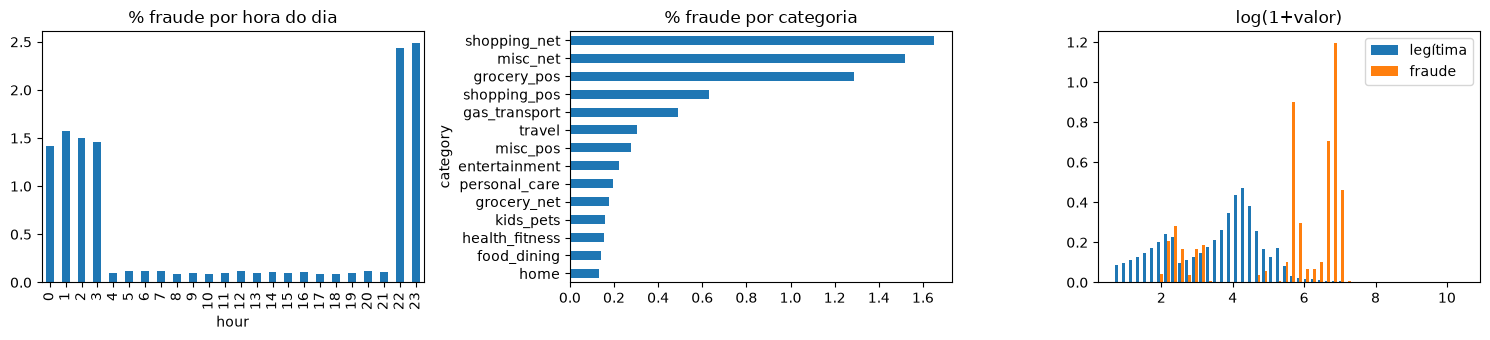

In [3]:
df["hour"] = pd.to_datetime(df.trans_time, format="%H:%M:%S").dt.hour
fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
df.groupby("hour").is_fraud.mean().mul(100).plot.bar(ax=ax[0], title="% fraude por hora do dia")
df.groupby("category").is_fraud.mean().mul(100).sort_values().plot.barh(ax=ax[1], title="% fraude por categoria")
ax[2].hist([np.log1p(df.amt[df.is_fraud == 0]), np.log1p(df.amt[df.is_fraud == 1])], bins=50, density=True,
           label=["legítima", "fraude"]); ax[2].legend(); ax[2].set_title("log(1+valor)")
plt.tight_layout(); plt.show()

## 2) Engenharia de features **que o ESP32 consegue calcular**

O terminal mantém, para cada cartão, um pequeno estado em RAM: timestamp da última compra, média móvel exponencial (EMA, α=0.1) dos valores e um *ring buffer* com as compras das últimas 24 h. A cada nova transação calcula:

| # | Feature | Origem no dispositivo |
|---|---------|----------------------|
| 0 | `log1p(valor)` | teclado |
| 1–2 | `sin/cos(2π·hora/24)` | RTC DS1307 (I2C) |
| 3 | idade do titular | perfil do cartão |
| 4 | `log1p(segundos desde a compra anterior)` | RTC + estado do cartão |
| 5 | `log1p(valor) − log1p(EMA anterior)` | estado do cartão |
| 6 | `log1p(nº compras nas últimas 24 h)` | ring buffer |
| 7 | `log1p(soma dos valores nas últimas 24 h)` | ring buffer |
| 8–21 | categoria *one-hot* (14) | teclado |

As 8 primeiras são padronizadas (`(x−μ)/σ`, μ e σ do **treino**) — esses μ/σ vão para um header C. **O código C do firmware replica exatamente esta função.**

In [4]:
CATEGORIES = ["entertainment", "food_dining", "gas_transport", "grocery_net", "grocery_pos", "health_fitness",
              "home", "kids_pets", "misc_net", "misc_pos", "personal_care", "shopping_net", "shopping_pos", "travel"]
CONT_FEATURES = ["log_amt", "hour_sin", "hour_cos", "age", "log_dt", "amt_vs_ema", "log_cnt24", "log_sum24"]
DT_DEFAULT = 7 * 24 * 3600     # primeira compra do cartão: assume 7 dias desde a anterior
EMA_ALPHA = 0.1
WIN_24H = 86400

def build_features(d: pd.DataFrame) -> pd.DataFrame:
    d = d.sort_values(["cc_num", "unix_time"]).copy()
    g = d.groupby("cc_num", sort=False)
    t = pd.to_datetime(d.trans_time, format="%H:%M:%S")
    hour = t.dt.hour + t.dt.minute / 60.0
    d["log_amt"] = np.log1p(d.amt)
    d["hour_sin"] = np.sin(2 * np.pi * hour / 24); d["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    d["age"] = (pd.to_datetime(d.trans_date) - pd.to_datetime(d.dob)).dt.days / 365.25
    dt = g.unix_time.diff().fillna(DT_DEFAULT).clip(lower=1)
    d["log_dt"] = np.log1p(dt)
    ema_prev = g.amt.transform(lambda s: s.ewm(alpha=EMA_ALPHA, adjust=False).mean().shift(1))
    d["amt_vs_ema"] = np.where(ema_prev.isna(), 0.0, np.log1p(d.amt) - np.log1p(ema_prev))
    # janela [t-24h, t) por cartão, excluindo a transação atual (mesma regra do firmware: ts_prev >= t-86400)
    d["ts"] = pd.to_datetime(d.unix_time, unit="s")
    roll = d.set_index("ts").groupby("cc_num", sort=False).amt.rolling(f"{WIN_24H}s", closed="left")
    d["log_cnt24"] = np.log1p(roll.count().fillna(0).values)
    d["log_sum24"] = np.log1p(roll.sum().fillna(0).values)
    for i, c in enumerate(CATEGORIES):
        d[f"cat_{c}"] = (d.category == c).astype(np.float32)
    return d

t0 = time.time(); feat = build_features(df); print(f"features em {time.time()-t0:.1f}s")
feat[CONT_FEATURES + ["is_fraud"]].groupby("is_fraud").mean().T

features em 6.7s


is_fraud,0,1
log_amt,3.495465,5.557551
hour_sin,-0.146779,0.017875
hour_cos,-0.000279,0.727185
age,38.431806,43.723885
log_dt,9.199443,8.403811
amt_vs_ema,-0.664204,0.364916
log_cnt24,1.433555,1.373400
log_sum24,4.744256,6.313610


### Divisão **por cartão** (clientes do teste nunca vistos no treino)
70% dos cartões para treino, 15% validação, 15% teste — todas as transações de um cartão ficam no mesmo conjunto (evita vazamento de identidade: o modelo não "decora" o cliente).

> **Por que não divisão temporal?** Testamos treino até mar/2020 e teste em jul–dez/2020: o PR-AUC caiu para ~0,17. O simulador tem *drift* entre os períodos (a mediana do valor das compras legítimas cai de US$ 52 para US$ 33 e a fração de compras legítimas noturnas cai de 27% para 17%), então o limiar aprendido em 2019 não transfere. Em produção isso é exatamente o que se monitora (Aula 3: *Monitoring* no ciclo de vida do modelo) e motivaria re-treino periódico.

In [5]:
cards = feat.cc_num.unique(); np.random.RandomState(SEED).shuffle(cards)
N_CARDS = len(cards); tr_cards, va_cards = set(cards[:int(.70 * N_CARDS)]), set(cards[int(.70 * N_CARDS):int(.85 * N_CARDS)])
split = np.where(feat.cc_num.isin(tr_cards), "tr", np.where(feat.cc_num.isin(va_cards), "va", "te"))
tr, va, te = feat[split == "tr"], feat[split == "va"], feat[split == "te"]
MU = tr[CONT_FEATURES].mean().values.astype(np.float32)
SIGMA = tr[CONT_FEATURES].std().values.astype(np.float32)
CAT_COLS = [f"cat_{c}" for c in CATEGORIES]

def to_xy(d):
    xc = (d[CONT_FEATURES].values.astype(np.float32) - MU) / SIGMA
    return np.hstack([xc, d[CAT_COLS].values.astype(np.float32)]), d.is_fraud.values.astype(np.float32)

Xtr, ytr = to_xy(tr); Xva, yva = to_xy(va); Xte, yte = to_xy(te)
N_FEATURES = Xtr.shape[1]
for nome, y in [("treino", ytr), ("validação", yva), ("teste", yte)]:
    print(f"{nome:10s} {len(y):>8d} amostras | fraude {y.mean()*100:.2f}%")
# Desbalanceamento (~0,5% de fraude): testamos class_weight, mas o PR-AUC ficou melhor sem peso.
# O desbalanceamento é tratado na escolha do threshold (seção 3.3), focada em recall.
CLASS_WEIGHT = None
print("N_FEATURES =", N_FEATURES, "| cartões treino/val/teste:", len(tr_cards), len(va_cards), N_CARDS - len(tr_cards) - len(va_cards))

treino      1268389 amostras | fraude 0.52%
validação    255596 amostras | fraude 0.56%
teste        259225 amostras | fraude 0.56%
N_FEATURES = 22 | cartões treino/val/teste: 695 149 149


## 3) Treinamento

### 3.1 Contagem de parâmetros e estimativa de memória (Aula 3)
Para uma camada `Dense`: **parâmetros = entradas × neurônios + neurônios (bias)**.
Tamanho ≈ parâmetros × bytes por parâmetro (4 em float32, 1 em int8) + overhead do FlatBuffer.

In [6]:
def make_mlp(hidden, name):
    m = keras.Sequential(name=name)
    m.add(keras.layers.InputLayer(input_shape=(N_FEATURES,)))
    for h in hidden:
        m.add(keras.layers.Dense(h, activation="relu"))
    m.add(keras.layers.Dense(1, activation="sigmoid"))
    return m

def params_by_hand(hidden):
    dims = [N_FEATURES] + list(hidden) + [1]
    return sum(a * b + b for a, b in zip(dims[:-1], dims[1:]))

BASE_HIDDEN = (32, 16)
base = make_mlp(BASE_HIDDEN, "mlp_base")
base.summary()
P = params_by_hand(BASE_HIDDEN)
print(f"parâmetros (à mão) = {P}  | Keras = {base.count_params()}")
print(f"estimativa Flash: float32 ≈ {P*4/1024:.1f} KB | int8 ≈ {P/1024:.1f} KB (+ overhead do FlatBuffer)")
print(f"maior tensor de ativação = {max(BASE_HIDDEN + (N_FEATURES,))} valores → RAM de ativações é minúscula")

Model: "mlp_base"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 dense (Dense)               (None, 32)                736       


 dense_1 (Dense)             (None, 16)                528       


...

Total params: 1281 (5.00 KB)


Trainable params: 1281 (5.00 KB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


parâmetros (à mão) = 1281  | Keras = 1281
estimativa Flash: float32 ≈ 5.0 KB | int8 ≈ 1.3 KB (+ overhead do FlatBuffer)
maior tensor de ativação = 32 valores → RAM de ativações é minúscula


### 3.2 Treino do modelo base (float32)

In [7]:
METRICS = [keras.metrics.AUC(curve="PR", name="pr_auc"), keras.metrics.Recall(name="recall")]
CB = [keras.callbacks.EarlyStopping(monitor="val_pr_auc", mode="max", patience=3, restore_best_weights=True)]
BATCH, EPOCHS = 2048, 25

def compile_fit(m, epochs=EPOCHS, lr=2e-3, callbacks=CB, **kw):
    m.compile(optimizer=keras.optimizers.Adam(lr), loss="binary_crossentropy", metrics=METRICS)
    return m.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=epochs, batch_size=BATCH,
                 class_weight=CLASS_WEIGHT, verbose=2, callbacks=callbacks, **kw)

hist = compile_fit(base)

Epoch 1/25


620/620 - 3s - loss: 0.0347 - pr_auc: 0.2116 - recall: 0.1780 - val_loss: 0.0133 - val_pr_auc: 0.6699 - val_recall: 0.4180 - 3s/epoch - 4ms/step


Epoch 2/25


620/620 - 2s - loss: 0.0112 - pr_auc: 0.6913 - recall: 0.4943 - val_loss: 0.0111 - val_pr_auc: 0.7239 - val_recall: 0.5302 - 2s/epoch - 3ms/step


Epoch 3/25


...

620/620 - 1s - loss: 0.0056 - pr_auc: 0.8828 - recall: 0.7354 - val_loss: 0.0060 - val_pr_auc: 0.8813 - val_recall: 0.7216 - 1s/epoch - 2ms/step


Epoch 24/25


620/620 - 1s - loss: 0.0055 - pr_auc: 0.8852 - recall: 0.7406 - val_loss: 0.0062 - val_pr_auc: 0.8752 - val_recall: 0.7328 - 1s/epoch - 2ms/step


Epoch 25/25


620/620 - 1s - loss: 0.0055 - pr_auc: 0.8850 - recall: 0.7380 - val_loss: 0.0062 - val_pr_auc: 0.8844 - val_recall: 0.7875 - 1s/epoch - 2ms/step


### 3.3 Escolha do *threshold* (na validação)
Em fraude, **falso negativo é o erro caro** (mesma lógica que a Aula 6 dá para manutenção preditiva: avaliar com *recall*). Escolhemos o limiar com **recall ≥ 90%** na validação e a maior precisão possível dentro dessa restrição.

In [8]:
TARGET_RECALL = 0.90
def pick_threshold(y, p, target=TARGET_RECALL):
    prec, rec, thr = precision_recall_curve(y, p)
    ok = np.where(rec[:-1] >= target)[0]
    i = ok[np.argmax(prec[ok])]
    return float(thr[i])

def report(y, p, thr):
    yhat = (p >= thr).astype(int)
    return dict(pr_auc=average_precision_score(y, p), roc_auc=roc_auc_score(y, p),
                precision=precision_score(y, yhat, zero_division=0), recall=recall_score(y, yhat),
                f1=f1_score(y, yhat))

p_va = base.predict(Xva, batch_size=8192, verbose=0).ravel()
THR = pick_threshold(yva, p_va)
p_te = base.predict(Xte, batch_size=8192, verbose=0).ravel()
print(f"threshold = {THR:.4f}")
print("validação:", {k: round(v, 4) for k, v in report(yva, p_va, THR).items()})
print("teste    :", {k: round(v, 4) for k, v in report(yte, p_te, THR).items()})
print(confusion_matrix(yte, (p_te >= THR).astype(int)))

threshold = 0.1529
validação: {'pr_auc': 0.8866, 'roc_auc': 0.9976, 'precision': 0.5758, 'recall': 0.9004, 'f1': 0.7024}


teste    : {'pr_auc': 0.8989, 'roc_auc': 0.9979, 'precision': 0.602, 'recall': 0.8956, 'f1': 0.72}


[[256907    862]
 [   152   1304]]


## 4) Compressão e conversão (Aulas 3 e 4)

Funções auxiliares: conversão TFLite com diferentes otimizações, avaliação com o **interpretador TFLite** (com quantização da entrada e desquantização da saída, como no notebook *hello_world* da aula) e medição da **tensor arena** com o runtime **TFLite Micro** — o mesmo motor que roda no ESP32.

In [9]:
def rep_dataset(n=2000):
    idx = np.random.RandomState(0).choice(len(Xtr), n, replace=False)
    # garante que exemplos de fraude (cauda da distribuição) entrem na calibração dos ranges int8
    idx = np.concatenate([idx, np.where(ytr == 1)[0][:500]])
    def gen():
        for i in idx:
            yield [Xtr[i:i + 1]]
    return gen

def convert(model, mode):
    conv = tf.lite.TFLiteConverter.from_keras_model(model)
    if mode == "float16":
        conv.optimizations = [tf.lite.Optimize.DEFAULT]; conv.target_spec.supported_types = [tf.float16]
    elif mode == "dynamic":
        conv.optimizations = [tf.lite.Optimize.DEFAULT]
    elif mode == "int8":
        conv.optimizations = [tf.lite.Optimize.DEFAULT]
        conv.representative_dataset = rep_dataset()
        conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        conv.inference_input_type = tf.int8; conv.inference_output_type = tf.int8
    return conv.convert()

def tflite_predict(blob, X):
    it = tf.lite.Interpreter(model_content=blob); inp = it.get_input_details()[0]; out = it.get_output_details()[0]
    it.resize_tensor_input(inp["index"], [len(X), X.shape[1]]); it.allocate_tensors()
    inp = it.get_input_details()[0]; out = it.get_output_details()[0]
    x = X
    if inp["dtype"] == np.int8:
        s, z = inp["quantization"]; x = np.clip(np.round(X / s + z), -128, 127).astype(np.int8)
    it.set_tensor(inp["index"], x); it.invoke(); y = it.get_tensor(out["index"]).astype(np.float32)
    if out["dtype"] == np.int8:
        s, z = out["quantization"]; y = (y - z) * s
    return y.ravel()

TFLM_PROBE = r'''
import sys, os, re, tempfile, numpy as np
from tflite_micro.python.tflite_micro import runtime
blob = open(sys.argv[1], "rb").read()
it = runtime.Interpreter.from_bytes(blob, arena_size=64 * 1024)
d = it.get_input_details(0); it.set_input(np.zeros(d["shape"], dtype=d["dtype"]), 0); it.invoke()
sys.stdout.flush(); it.print_allocations(); sys.stdout.flush()
'''
def tflm_arena(blob):
    # Mede a RAM que o TFLite Micro realmente aloca (tensor arena) — o mesmo runtime do ESP32.
    # Roda num subprocesso: modelos fp16/híbridos não são suportados pelo TFLM e abortam o processo.
    import sys, re
    with tempfile.NamedTemporaryFile(suffix=".tflite", delete=False) as f:
        f.write(blob)
    r = subprocess.run([sys.executable, "-c", TFLM_PROBE, f.name], capture_output=True, text=True)
    m = re.search(r"Arena allocation total (\d+) bytes", r.stdout + r.stderr)  # o TFLM loga em stderr
    return int(m.group(1)) if m else "não suportado"

def gz(blob):
    return len(gzip.compress(blob, 9))

RESULTS = []
def register(name, blob, X=Xte, y=yte, note=""):
    p = tflite_predict(blob, X)
    r = report(y, p, THR)
    row = dict(modelo=name, bytes=len(blob), gzip=gz(blob), arena_tflm=tflm_arena(blob), **{k: round(v, 4) for k, v in r.items()}, obs=note)
    RESULTS.append(row); return blob, p

blobs = {}
blobs["float32"], _ = register("float32 (baseline)", convert(base, "float32"))
blobs["float16"], _ = register("float16", convert(base, "float16"), note="TFLM não executa fp16")
blobs["dynamic"], _ = register("dynamic range (pesos int8)", convert(base, "dynamic"), note="híbrido: TFLM não executa")
blobs["int8"], p_int8 = register("PTQ int8 completo", convert(base, "int8"), note="entrada/saída int8")
pd.DataFrame(RESULTS)

INFO:tensorflow:Assets written to: /tmp/tmpo9ziawjo/assets


INFO:tensorflow:Assets written to: /tmp/tmp08vmuda5/assets


INFO:tensorflow:Assets written to: /tmp/tmpx0c3cy38/assets


INFO:tensorflow:Assets written to: /tmp/tmp8tpk3oid/assets


,modelo,bytes,gzip,arena_tflm,pr_auc,roc_auc,precision,recall,f1,obs
0,float32 (baseline),7156,5797,1696,0.8989,0.9979,0.6020,0.8956,0.7200,
1,float16,5388,3694,não suportado,0.8989,0.9979,0.6020,0.8956,0.7200,TFLM não executa fp16
2,dynamic range (pesos int8),7156,5798,1696,0.8989,0.9979,0.6020,0.8956,0.7200,híbrido: TFLM não executa
3,PTQ int8 completo,4968,2845,1984,0.8942,0.9954,0.5974,0.9011,0.7185,entrada/saída int8


### 4.1 Quantização manual — entendendo `scale` e `zero_point`
A quantização afim (assimétrica) do TFLite usa `q = round(x / scale) + zero_point`. O firmware faz exatamente isto antes de chamar `Invoke()`.

In [10]:
it = tf.lite.Interpreter(model_content=blobs["int8"]); it.allocate_tensors()
inp, out = it.get_input_details()[0], it.get_output_details()[0]
IN_SCALE, IN_ZP = inp["quantization"]; OUT_SCALE, OUT_ZP = out["quantization"]
print(f"entrada: scale={IN_SCALE:.6f} zero_point={IN_ZP} | saída: scale={OUT_SCALE:.6f} zero_point={OUT_ZP}")
x = Xte[0]; q = np.clip(np.round(x / IN_SCALE + IN_ZP), -128, 127)
print("x[:6]      =", np.round(x[:6], 3)); print("q[:6]      =", q[:6].astype(int))
print("x̂ = (q-zp)·s =", np.round((q[:6] - IN_ZP) * IN_SCALE, 3), "→ erro de arredondamento ≤ scale/2 =", round(IN_SCALE / 2, 4))
THR_Q = int(np.clip(np.round(THR / OUT_SCALE + OUT_ZP), -128, 127))
print(f"threshold {THR:.4f} em int8 → {THR_Q}  (dá para comparar direto na saída quantizada)")
print("Pesos por camada (tensor int8):")
for d in it.get_tensor_details():
    if d["dtype"] == np.int8 and len(d["shape"]) == 2:
        print(f"   {d['name'][:60]:60s} {tuple(d['shape'])}  scales por canal: {len(d['quantization_parameters']['scales'])}")

entrada: scale=0.033759 zero_point=17 | saída: scale=0.003906 zero_point=-128
x[:6]      = [-0.885  0.227  1.408  1.641  2.367  0.498]
q[:6]      = [-9 24 59 66 87 32]
x̂ = (q-zp)·s = [-0.878  0.236  1.418  1.654  2.363  0.506] → erro de arredondamento ≤ scale/2 = 0.0169
threshold 0.1529 em int8 → -89  (dá para comparar direto na saída quantizada)
Pesos por camada (tensor int8):
   serving_default_input_1:0                                    (np.int32(1), np.int32(22))  scales por canal: 1
   tfl.pseudo_qconst1                                           (np.int32(1), np.int32(16))  scales por canal: 1
   tfl.pseudo_qconst3                                           (np.int32(16), np.int32(32))  scales por canal: 16
   tfl.pseudo_qconst5                                           (np.int32(32), np.int32(22))  scales por canal: 32
   mlp_base/dense/MatMul;mlp_base/dense/Relu;mlp_base/dense/Bia (np.int32(1), np.int32(32))  scales por canal: 1
   mlp_base/dense_1/MatMul;mlp_base/dense_1/Relu;

### 4.2 Quantization Aware Training (QAT)
O modelo "simula" a quantização durante o *fine-tuning* (*fake quant*), aprendendo a compensar o erro.

In [11]:
qat = tfmot.quantization.keras.quantize_model(base)   # cópia do modelo base com nós de fake-quant
compile_fit(qat, epochs=4, lr=5e-4)
blobs["qat"], _ = register("QAT int8", convert(qat, "int8"), note="fine-tuning 4 épocas")

Epoch 1/4


620/620 - 3s - loss: 0.0054 - pr_auc: 0.8921 - recall: 0.7546 - val_loss: 0.0059 - val_pr_auc: 0.8875 - val_recall: 0.6992 - 3s/epoch - 5ms/step


Epoch 2/4


620/620 - 2s - loss: 0.0052 - pr_auc: 0.8964 - recall: 0.7476 - val_loss: 0.0059 - val_pr_auc: 0.8856 - val_recall: 0.7518 - 2s/epoch - 3ms/step


Epoch 3/4


620/620 - 2s - loss: 0.0052 - pr_auc: 0.8980 - recall: 0.7479 - val_loss: 0.0058 - val_pr_auc: 0.8872 - val_recall: 0.7433 - 2s/epoch - 3ms/step


Epoch 4/4


620/620 - 2s - loss: 0.0052 - pr_auc: 0.8978 - recall: 0.7482 - val_loss: 0.0058 - val_pr_auc: 0.8874 - val_recall: 0.7321 - 2s/epoch - 3ms/step


INFO:tensorflow:Assets written to: /tmp/tmpjrp7e8u1/assets


### 4.3 Pruning (poda por magnitude)
Zera os pesos de menor magnitude até 75% de esparsidade. O `.tflite` **não encolhe sozinho** (os zeros continuam armazenados), mas **comprime muito melhor** (gzip) — e, combinado com int8, dá a máxima compressão.

In [12]:
SPARSITY = 0.75
steps = math.ceil(len(Xtr) / BATCH) * 4
prune = tfmot.sparsity.keras.prune_low_magnitude(base, pruning_schedule=
        tfmot.sparsity.keras.PolynomialDecay(0.0, SPARSITY, begin_step=0, end_step=int(steps * 0.7)))
compile_fit(prune, epochs=4, lr=5e-4, callbacks=[tfmot.sparsity.keras.UpdatePruningStep()])
pruned = tfmot.sparsity.keras.strip_pruning(prune)
w = np.concatenate([l.get_weights()[0].ravel() for l in pruned.layers])
print(f"esparsidade real dos kernels: {(w == 0).mean()*100:.1f}%")
blobs["pruned_f32"], _ = register("pruning 75% float32", convert(pruned, "float32"))
blobs["pruned_int8"], _ = register("pruning 75% + int8", convert(pruned, "int8"))

Epoch 1/4


620/620 - 3s - loss: 0.0064 - pr_auc: 0.8615 - recall: 0.7163 - val_loss: 0.0116 - val_pr_auc: 0.7337 - val_recall: 0.5940 - 3s/epoch - 6ms/step


Epoch 2/4


620/620 - 1s - loss: 0.0106 - pr_auc: 0.7023 - recall: 0.5609 - val_loss: 0.0125 - val_pr_auc: 0.6616 - val_recall: 0.4116 - 1s/epoch - 2ms/step


Epoch 3/4


...

Epoch 4/4


620/620 - 1s - loss: 0.0102 - pr_auc: 0.7249 - recall: 0.5091 - val_loss: 0.0106 - val_pr_auc: 0.7392 - val_recall: 0.5210 - 1s/epoch - 2ms/step


esparsidade real dos kernels: 75.0%


INFO:tensorflow:Assets written to: /tmp/tmp6udk4bz3/assets


INFO:tensorflow:Assets written to: /tmp/tmpm_1tvjj9/assets


### 4.4 Clustering de pesos (compartilhamento)
Cada camada passa a ter só **16 valores distintos** de peso (centróides). Também ajuda na compressão (gzip) e combina com int8.

In [13]:
clu = tfmot.clustering.keras.cluster_weights(base, number_of_clusters=16,
        cluster_centroids_init=tfmot.clustering.keras.CentroidInitialization.KMEANS_PLUS_PLUS)
compile_fit(clu, epochs=3, lr=3e-4, callbacks=[])
clustered = tfmot.clustering.keras.strip_clustering(clu)
print("valores distintos por camada:", [len(np.unique(l.get_weights()[0])) for l in clustered.layers])
blobs["clustered_int8"], _ = register("clustering 16 + int8", convert(clustered, "int8"))

Epoch 1/3


620/620 - 3s - loss: 0.0097 - pr_auc: 0.7402 - recall: 0.5273 - val_loss: 0.0101 - val_pr_auc: 0.7553 - val_recall: 0.5309 - 3s/epoch - 4ms/step


Epoch 2/3


620/620 - 1s - loss: 0.0093 - pr_auc: 0.7558 - recall: 0.5485 - val_loss: 0.0096 - val_pr_auc: 0.7675 - val_recall: 0.5449 - 1s/epoch - 2ms/step


Epoch 3/3


620/620 - 1s - loss: 0.0091 - pr_auc: 0.7554 - recall: 0.5600 - val_loss: 0.0092 - val_pr_auc: 0.7753 - val_recall: 0.5673 - 1s/epoch - 2ms/step


valores distintos por camada: [16, 16, 5]


INFO:tensorflow:Assets written to: /tmp/tmpdxn0qwk9/assets


### 4.5 Knowledge Distillation (professor → aluno)
Professor grande (128-64-32). O aluno (16-8, ~4× menos parâmetros que a base) aprende com os **soft targets** do professor (temperatura T) + rótulos reais.

In [14]:
teacher = make_mlp((128, 64, 32), "professor")
compile_fit(teacher, epochs=EPOCHS)
p_teacher = teacher.predict(Xte, batch_size=8192, verbose=0).ravel()
print("professor:", {k: round(v, 4) for k, v in report(yte, p_teacher, pick_threshold(yva, teacher.predict(Xva, batch_size=8192, verbose=0).ravel())).items()},
      "| params:", teacher.count_params())

class Distiller(keras.Model):
    def __init__(self, student, teacher, T=3.0, alpha=0.5):
        super().__init__(); self.s, self.t, self.T, self.alpha = student, teacher, T, alpha
        self.bce = keras.losses.BinaryCrossentropy()
    def _logit(self, p):
        p = tf.clip_by_value(p, 1e-6, 1 - 1e-6); return tf.math.log(p / (1 - p))
    def train_step(self, data):
        x, y, sw = keras.utils.unpack_x_y_sample_weight(data)
        soft_t = tf.sigmoid(self._logit(self.t(x, training=False)) / self.T)
        with tf.GradientTape() as tape:
            ps = self.s(x, training=True)
            soft_s = tf.sigmoid(self._logit(ps) / self.T)
            loss = self.alpha * self.bce(y, ps, sample_weight=sw) + (1 - self.alpha) * (self.T ** 2) * self.bce(soft_t, soft_s)
        self.optimizer.apply_gradients(zip(tape.gradient(loss, self.s.trainable_variables), self.s.trainable_variables))
        return {"loss": loss}
    def call(self, x):
        return self.s(x)

student = make_mlp((16, 8), "aluno")
dist = Distiller(student, teacher); dist.compile(optimizer=keras.optimizers.Adam(2e-3))
dist.fit(Xtr, ytr.reshape(-1, 1), epochs=10, batch_size=BATCH, class_weight=CLASS_WEIGHT, verbose=2)

scratch = make_mlp((16, 8), "aluno_sem_professor"); compile_fit(scratch, epochs=10, callbacks=[])
print(f"params: base={base.count_params()} | aluno={student.count_params()} | professor={teacher.count_params()}")
blobs["student_int8"], _ = register("aluno destilado (16-8) int8", convert(student, "int8"), note="KD T=3, α=0.5")
blobs["scratch_int8"], _ = register("aluno sem professor (16-8) int8", convert(scratch, "int8"), note="controle da KD")

Epoch 1/25


620/620 - 4s - loss: 0.0222 - pr_auc: 0.4628 - recall: 0.3808 - val_loss: 0.0099 - val_pr_auc: 0.7647 - val_recall: 0.5610 - 4s/epoch - 6ms/step


Epoch 2/25


620/620 - 3s - loss: 0.0086 - pr_auc: 0.7792 - recall: 0.5939 - val_loss: 0.0080 - val_pr_auc: 0.8189 - val_recall: 0.6367 - 3s/epoch - 5ms/step


Epoch 3/25


...

Epoch 10/10


620/620 - 1s - loss: 0.0082 - pr_auc: 0.7891 - recall: 0.6023 - val_loss: 0.0086 - val_pr_auc: 0.7952 - val_recall: 0.6094 - 1s/epoch - 2ms/step


params: base=49 | aluno=513 | professor=13313


INFO:tensorflow:Assets written to: /tmp/tmpdjt_ewda/assets


INFO:tensorflow:Assets written to: /tmp/tmptju5h17s/assets


## 5) Comparação final

Mesma métrica e **mesmo threshold** para todos, no conjunto de **teste** (cartões nunca vistos).

,modelo,bytes,gzip,arena_tflm,pr_auc,roc_auc,precision,recall,f1,obs,vs_float32
0,float32 (baseline),7156,5797,1696,0.8989,0.9979,0.6020,0.8956,0.7200,,1.00
1,float16,5388,3694,não suportado,0.8989,0.9979,0.6020,0.8956,0.7200,TFLM não executa fp16,0.75
2,dynamic range (pesos int8),7156,5798,1696,0.8989,0.9979,0.6020,0.8956,0.7200,híbrido: TFLM não executa,1.00
3,PTQ int8 completo,4968,2845,1984,0.8942,0.9954,0.5974,0.9011,0.7185,entrada/saída int8,0.69
4,QAT int8,4168,2398,1600,0.8986,0.9932,0.7902,0.8510,0.8194,fine-tuning 4 épocas,0.58
5,pruning 75% float32,7156,2811,1696,0.7456,0.9905,0.5898,0.7012,0.6407,,1.00
6,pruning 75% + int8,4968,2133,1984,0.7394,0.9849,0.6020,0.6930,0.6443,,0.69
7,clustering 16 + int8,4968,2043,1984,0.7762,0.9851,0.6488,0.7335,0.6886,,0.69
8,aluno destilado (16-8) int8,3536,1810,1776,0.7838,0.9677,0.7547,0.6848,0.7180,"KD T=3, α=0.5",0.49
9,aluno sem professor (16-8) int8,3656,1843,1776,0.8066,0.9910,0.6614,0.7823,0.7168,controle da KD,0.51


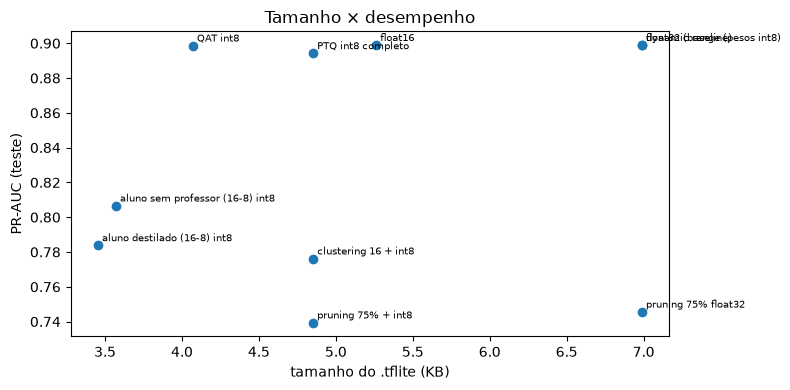

In [15]:
res = pd.DataFrame(RESULTS)
res["vs_float32"] = (res.bytes / res.bytes.iloc[0]).round(2)
display(res)
res.to_csv(OUT / "comparacao_compressao.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(res.bytes / 1024, res.pr_auc)
for _, r in res.iterrows():
    ax.annotate(r.modelo, (r.bytes / 1024, r.pr_auc), fontsize=7, xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("tamanho do .tflite (KB)"); ax.set_ylabel("PR-AUC (teste)"); ax.set_title("Tamanho × desempenho")
plt.tight_layout(); plt.savefig(OUT / "tamanho_vs_prauc.png", dpi=120); plt.show()

### Leitura crítica da tabela

* **PTQ int8** reduz o arquivo para ~70% do float32 (pesos de 4 → 1 byte; o resto é overhead fixo do FlatBuffer, relevante num modelo tão pequeno) e perde só ~0,005 de PR-AUC.
* **QAT** recupera essa perda (PR-AUC ≈ float32) e gera o menor `.tflite` entre os modelos completos.
* **Pruning 75%** e **clustering 16** não diminuem o `.tflite` (os zeros/centróides continuam armazenados como int8). Só ganham no **gzip**, que só ajuda se o modelo for transmitido comprimido (OTA). E custam PR-AUC: com ~1,3 mil parâmetros, não há redundância sobrando para cortar.
* **Destilação não ajudou aqui:** o aluno destilado ficou abaixo do aluno treinado só com os rótulos. Com 1,2 milhão de exemplos, o aluno já aprende bem com os rótulos. A KD costuma render mais com poucos dados ou com um professor muito superior. É um resultado negativo honesto, e o controle "aluno sem professor" existe justamente para mostrá-lo.
* **fp16** e **dynamic range** reduzem o arquivo, mas **não rodam no TFLite Micro**. Por isso, para microcontrolador, a quantização tem de ser int8 completa.

### Escolha do modelo para o ESP32-S3
Critério: **rodar no TFLite Micro** (int8 completo) e ter o menor tamanho **sem perder PR-AUC** em relação ao float32.

* fp16 e *dynamic range* ficam de fora: o TFLM não executa esses formatos.
* Pruning e clustering só reduzem o tamanho **comprimido** (gzip). O `.tflite` continua igual, e na Flash do ESP32 o modelo não fica comprimido. Para um modelo de ~5 KB, o ganho não compensa a perda de PR-AUC.
* **QAT int8** recupera a pequena perda do PTQ (PR-AUC ≈ float32) e ainda fica menor → **é o escolhido**.

O threshold é **recalibrado na validação com o próprio modelo embarcado** (a quantização desloca um pouco as probabilidades).

In [16]:
DEPLOY = os.environ.get("DEPLOY", "qat")
deploy_blob = blobs[DEPLOY]
THR = pick_threshold(yva, tflite_predict(deploy_blob, Xva))       # threshold do modelo embarcado
it = tf.lite.Interpreter(model_content=deploy_blob); it.allocate_tensors()
(IN_SCALE, IN_ZP), (OUT_SCALE, OUT_ZP) = it.get_input_details()[0]["quantization"], it.get_output_details()[0]["quantization"]
THR_Q = int(np.clip(np.ceil(THR / OUT_SCALE + OUT_ZP), -128, 127))  # alerta se q >= THR_Q
print("teste (modelo embarcado):", {k: round(v, 4) for k, v in report(yte, tflite_predict(deploy_blob, Xte), THR).items()},
      f"| threshold {THR:.4f} → int8 {THR_Q}")
(OUT / "fraude_model.tflite").write_bytes(deploy_blob)

from tflite_micro.python.tflite_micro import runtime
tflm = runtime.Interpreter.from_bytes(deploy_blob, arena_size=16 * 1024)
ARENA_USED = tflm_arena(deploy_blob)   # medido no host 64-bit (ponteiros maiores) → no ESP32 tende a ser um pouco menor

# bit-exactness: TFLM (C++) vs interpretador TFLite em 300 amostras de teste
it = tf.lite.Interpreter(model_content=deploy_blob); it.allocate_tensors()
ii, oo = it.get_input_details()[0], it.get_output_details()[0]
s_in, z_in = ii["quantization"]; diffs = maxlsb = 0
sample = np.concatenate([np.where(yte == 1)[0][:100], np.arange(200)])
for i in sample:
    q = np.clip(np.round(Xte[i:i+1] / s_in + z_in), -128, 127).astype(np.int8)
    it.set_tensor(ii["index"], q); it.invoke(); a = it.get_tensor(oo["index"])
    tflm.set_input(q, 0); tflm.invoke(); b = tflm.get_output(0)
    diffs += int(np.any(a != b)); maxlsb = max(maxlsb, int(np.abs(a.astype(int) - b.astype(int)).max()))
print(f"modelo: {DEPLOY} | {len(deploy_blob)} bytes | tensor arena (TFLM): {ARENA_USED} bytes | TFLite×TFLM: {len(sample)-diffs}/{len(sample)} saídas idênticas, diferença máx. {maxlsb} LSB")

teste (modelo embarcado): {'pr_auc': 0.8986, 'roc_auc': 0.9932, 'precision': 0.6352, 'recall': 0.8922, 'f1': 0.7421} | threshold 0.0742 → int8 -109
modelo: qat | 4168 bytes | tensor arena (TFLM): 1600 bytes | TFLite×TFLM: 280/300 saídas idênticas, diferença máx. 12 LSB


## 6) Exportação para o firmware (ESP-IDF)

* `model_data.cc/.h` — equivalente ao `xxd -i fraude_model.tflite` da Aula 4, com `alignas(16)` (o TFLM exige alinhamento).
* `fraud_params.h` — μ, σ, ordem das categorias, threshold (float e int8), parâmetros de quantização e constantes das features.
* `replay_data.h` — transações **brutas** (valor, categoria, horário, Δt) de cartões reais do conjunto de teste com rajadas de fraude, para o modo "replay" do terminal. O firmware calcula as features sozinho.

In [17]:
def to_c_array(blob, name):
    hexs = [f"0x{b:02x}" for b in blob]
    lines = ",\n".join("  " + ", ".join(hexs[i:i + 12]) for i in range(0, len(hexs), 12))
    cc = (f'// Gerado automaticamente a partir de {name}.tflite (equivalente a `xxd -i`).\n#include "{name}.h"\n\n'
          f"alignas(16) const unsigned char g_{name}[] = {{\n{lines}\n}};\nconst unsigned int g_{name}_len = {len(blob)};\n")
    h = (f"#pragma once\n// Modelo TFLite como array C (fica na Flash).\nextern const unsigned char g_{name}[];\nextern const unsigned int g_{name}_len;\n")
    return cc, h

def c_floats(v): return ", ".join(f"{x:.8f}f" for x in v)

cc, h = to_c_array(deploy_blob, "model_data")
arena = int(math.ceil(((ARENA_USED or 4096) * 1.5) / 1024.0) * 1024)  # folga de 50% (Aula 3: "adicione uma folga")
params_h = f'''#pragma once
// Gerado pelo notebook 01_antifraude_treino_compressao.ipynb — NÃO editar à mão.
// Modelo: {DEPLOY} | {len(deploy_blob)} bytes | threshold escolhido na validação com recall >= {TARGET_RECALL:.0%}
#include <stdint.h>

#define FRAUD_N_FEATURES      {N_FEATURES}
#define FRAUD_N_CONT          {len(CONT_FEATURES)}
#define FRAUD_N_CATEGORIES    {len(CATEGORIES)}
#define FRAUD_DT_DEFAULT_S    {DT_DEFAULT}u
#define FRAUD_EMA_ALPHA       {EMA_ALPHA}f
#define FRAUD_WIN_24H_S       {WIN_24H}u
#define FRAUD_TENSOR_ARENA    {arena}   // medido no TFLM: {ARENA_USED} bytes (+50% de folga)

#define FRAUD_THRESHOLD       {THR:.6f}f
#define FRAUD_THRESHOLD_Q     ({THR_Q})
#define FRAUD_IN_SCALE        {IN_SCALE:.10f}f
#define FRAUD_IN_ZERO_POINT   ({IN_ZP})
#define FRAUD_OUT_SCALE       {OUT_SCALE:.10f}f
#define FRAUD_OUT_ZERO_POINT  ({OUT_ZP})

// ordem: {", ".join(CONT_FEATURES)}
__attribute__((unused)) static const float kFraudMu[FRAUD_N_CONT]    = {{ {c_floats(MU)} }};
__attribute__((unused)) static const float kFraudSigma[FRAUD_N_CONT] = {{ {c_floats(SIGMA)} }};

__attribute__((unused)) static const char *const kFraudCategoryKeys[FRAUD_N_CATEGORIES] = {{ {", ".join(f'"{c}"' for c in CATEGORIES)} }};
'''
# ---- replay: cartões do teste com rajada de fraude ----
te_raw = te.copy()
cards = te_raw.groupby("cc_num").is_fraud.sum().sort_values(ascending=False)
rows = []
for card in cards.index[:3]:
    c = te_raw[te_raw.cc_num == card].reset_index(drop=True)
    first = c.index[c.is_fraud == 1][0]
    seg = c.iloc[max(0, first - 30): first + 15]          # 30 compras normais "esquentam" o histórico, depois a rajada
    age = float(seg.age.iloc[0])
    prev = None
    for _, r in seg.iterrows():
        dt = 0 if prev is None else int(r.unix_time - prev); prev = r.unix_time
        t = pd.to_datetime(r.trans_time, format="%H:%M:%S")
        rows.append((len(rows), float(r.amt), CATEGORIES.index(r.category), t.hour, t.minute, dt, int(r.is_fraud), age, int(card)))
# reindexa id do cartão (0..2)
card_ids = {c: i for i, c in enumerate(dict.fromkeys(r[-1] for r in rows))}
lines = []
for r in rows:
    lines.append(f"  {{ {card_ids[r[-1]]}, {r[1]:.2f}f, {r[2]}, {r[3]}, {r[4]}, {r[5]}u, {r[6]} }},")
ages = {card_ids[r[-1]]: r[7] for r in rows}
replay_h = f'''#pragma once
// Transações BRUTAS de cartões do conjunto de TESTE (nunca vistos no treino): {len(card_ids)} cartões com rajada de fraude.
// O firmware recalcula as features a partir destes eventos (mesma função do notebook).
#include <stdint.h>
typedef struct {{
  uint8_t card;      // índice do cartão (0..{len(card_ids)-1})
  float amount;      // valor
  uint8_t category;  // índice em kFraudCategoryKeys
  uint8_t hour, minute;
  uint32_t dt_s;     // segundos desde a compra anterior DESTE cartão no replay (0 = primeira)
  uint8_t label;     // rótulo real (1 = fraude) — só para mostrar acerto/erro no display
}} replay_tx_t;

#define REPLAY_N_CARDS {len(card_ids)}
__attribute__((unused)) static const float kReplayCardAge[REPLAY_N_CARDS] = {{ {", ".join(f"{ages[i]:.2f}f" for i in range(len(card_ids)))} }};
#define REPLAY_LEN {len(rows)}
__attribute__((unused)) static const replay_tx_t kReplay[REPLAY_LEN] = {{
{chr(10).join(lines)}
}};
'''
for path in [OUT] + ([FIRMWARE_MAIN] if FIRMWARE_MAIN.exists() else []):
    (path / "model_data.cc").write_text(cc); (path / "model_data.h").write_text(h)
    (path / "fraud_params.h").write_text(params_h); (path / "replay_data.h").write_text(replay_h)
    print("escrito em", path.resolve())

# vetores de teste para validar o firmware: features calculadas aqui para as 5 primeiras do replay
json.dump(dict(model=DEPLOY, bytes=len(deploy_blob), arena_used=ARENA_USED, arena_cfg=arena, threshold=THR, threshold_q=THR_Q,
               in_scale=float(IN_SCALE), in_zp=int(IN_ZP), out_scale=float(OUT_SCALE), out_zp=int(OUT_ZP),
               results=RESULTS), open(OUT / "resumo.json", "w"), indent=1, default=str)
print(params_h[:900])

escrito em ./01_antifraude/notebooks/artefatos_antifraude
escrito em ./01_antifraude/firmware/main
#pragma once
// Gerado pelo notebook 01_antifraude_treino_compressao.ipynb — NÃO editar à mão.
// Modelo: qat | 4168 bytes | threshold escolhido na validação com recall >= 90%
#include <stdint.h>

#define FRAUD_N_FEATURES      22
#define FRAUD_N_CONT          8
#define FRAUD_N_CATEGORIES    14
#define FRAUD_DT_DEFAULT_S    604800u
#define FRAUD_EMA_ALPHA       0.1f
#define FRAUD_WIN_24H_S       86400u
#define FRAUD_TENSOR_ARENA    3072   // medido no TFLM: 1600 bytes (+50% de folga)

#define FRAUD_THRESHOLD       0.074219f
#define FRAUD_THRESHOLD_Q     (-109)
#define FRAUD_IN_SCALE        0.0422093123f
#define FRAUD_IN_ZERO_POINT   (-12)
#define FRAUD_OUT_SCALE       0.0039062500f
#define FRAUD_OUT_ZERO_POINT  (-128)

// ordem: log_amt, hour_sin, hour_cos, age, log_dt, amt_vs_ema, log_cnt24, log_sum24
__attribute__((unused)) static const float kFraudMu[FRAUD_N_CONT]    = { 3.51676130f, -


## 7) Conferência: o pipeline C reproduz o Python?
Simulamos aqui, em Python puro e **na mesma ordem do firmware**, o processamento do replay (estado por cartão → features → padronização → quantização → modelo int8). A inferência usa o runtime **TFLite Micro**, o mesmo do ESP32: os kernels de referência do TFLM (ex.: `LOGISTIC`) arredondam um pouco diferente do interpretador TFLite, e a diferença chega a alguns LSB na saída. O firmware imprime no monitor serial as mesmas colunas, então dá para comparar linha a linha.

In [18]:
class CardState:
    def __init__(self, age): self.age, self.last_ts, self.ema, self.hist = age, None, None, []
def device_features(st, ts, amt, cat, hour, minute):
    h = hour + minute / 60.0
    dt = DT_DEFAULT if st.last_ts is None else max(1, ts - st.last_ts)
    recent = [(t, a) for t, a in st.hist if t >= ts - WIN_24H]
    cont = [math.log1p(amt), math.sin(2*math.pi*h/24), math.cos(2*math.pi*h/24), st.age, math.log1p(dt),
            0.0 if st.ema is None else math.log1p(amt) - math.log1p(st.ema), math.log1p(len(recent)), math.log1p(sum(a for _, a in recent))]
    x = np.zeros(N_FEATURES, np.float32); x[:8] = (np.array(cont, np.float32) - MU) / SIGMA; x[8 + cat] = 1
    st.ema = amt if st.ema is None else (1 - EMA_ALPHA) * st.ema + EMA_ALPHA * amt
    st.hist = recent + [(ts, amt)]; st.last_ts = ts
    return x

it = tf.lite.Interpreter(model_content=deploy_blob); it.allocate_tensors()
ii, oo = it.get_input_details()[0], it.get_output_details()[0]
states, clock, out_rows = {}, {}, []
for (k, amt, cat, hh, mm, dt, lab, age, card) in rows:
    cid = card_ids[card]; st = states.setdefault(cid, CardState(age))
    clock[cid] = (clock.get(cid, 1_600_000_000) + dt)
    x = device_features(st, clock[cid], amt, cat, hh, mm)
    v = x / np.float32(IN_SCALE); q = np.clip(np.sign(v) * np.floor(np.abs(v) + .5) + IN_ZP, -128, 127).astype(np.int8)  # = lroundf do C
    tflm.set_input(q[None], 0); tflm.invoke(); yq = int(tflm.get_output(0)[0, 0])   # mesmo runtime do ESP32
    out_rows.append(dict(i=k, card=cid, amt=amt, cat=CATEGORIES[cat], hora=f"{hh:02d}:{mm:02d}", y_q=yq,
                         p=round((yq - OUT_ZP) * OUT_SCALE, 3), alerta=int(yq >= THR_Q), real=lab))
rep = pd.DataFrame(out_rows); rep.to_csv(OUT / "replay_esperado.csv", index=False)
print(f"replay: {len(rep)} transações | recall {rep[rep.real==1].alerta.mean():.2f} | falsos alarmes {int(((rep.alerta==1)&(rep.real==0)).sum())}")
rep.tail(20)

replay: 133 transações | recall 0.98 | falsos alarmes 1


,i,card,amt,cat,hora,y_q,p,alerta,real
113,113,2,45.81,shopping_pos,18:59,-128,0.000,0,0
114,114,2,19.86,shopping_pos,16:18,-128,0.000,0,0
115,115,2,3.47,shopping_pos,22:35,-128,0.000,0,0
116,116,2,134.91,shopping_pos,23:24,-128,0.000,0,0
117,117,2,4.11,shopping_pos,17:49,-128,0.000,0,0
118,118,2,756.17,misc_net,00:33,85,0.832,1,1
119,119,2,1051.76,grocery_pos,00:52,115,0.949,1,1
120,120,2,126.05,shopping_net,01:19,113,0.941,1,1
121,121,2,543.11,grocery_pos,02:02,122,0.977,1,1
122,122,2,363.03,grocery_pos,02:06,126,0.992,1,1
